In [8]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [9]:
class AgentState(TypedDict):
    values: List[int]
    operation: str
    result: str

In [10]:
def calc_node(state: AgentState) -> AgentState:
    """Adds or subtracts the values based on the operation and stores the result."""

    print(state)
    result = 0
    for value in state["values"]:
        if state["operation"] == "sub":
            result -= value
        else:
            result += value

    state["result"] = f"the result is {result}"

    return state

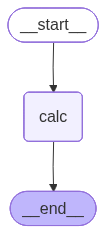

In [11]:
graph = StateGraph(AgentState)


graph.add_node("calc", calc_node)

graph.set_entry_point("calc")
graph.set_finish_point("calc")

app = graph.compile()

app

In [12]:
result = app.invoke({"values": [2, 7, 9, 4], "operation": "add"})
result

{'values': [2, 7, 9, 4], 'operation': 'add'}


{'values': [2, 7, 9, 4], 'operation': 'add', 'result': 'the result is 22'}